# Assignment 1 2AMM10 2025-2026

## Group: [Fill in your group name]
### Member 1: [Fill in your name]
### Member 2: [Fill in your name]
### Member 3: [Fill in your name]

In [2]:
import torch
import json
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random
import numpy as np

## Global Variables ##
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
DATA_DIR = "./data"
DROWSY_DATASET_DIR = Path(
    DATA_DIR, "drowsy_graph_dataset"
)  # Path to the drowsy dataset
OBJ_CLS_DATASET_DIR = Path(
    DATA_DIR, "bdd8cls_balanced_300_30"
)  # Path to the object classification dataset
DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )
)

# Task 1

In [ ]:
class DrowsyFaceGraphDataset(Dataset):
    def __init__(self, root, split="train"):
        self.root = Path(root)
        self.split = split

        data_path = self.root / f"{split}.pt"
        class_to_id_path = self.root / "class_to_id.json"
        id_to_class_path = self.root / "id_to_class.json"

        if not data_path.exists():
            raise FileNotFoundError(f"Could not find {data_path}")

        self.graphs = torch.load(data_path, weights_only=False)

        with open(class_to_id_path, "r") as f:
            self.class_to_id = json.load(f)

        with open(id_to_class_path, "r") as f:
            self.id_to_class = json.load(f)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]


train_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train")
test_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test")
class_to_id: dict = train_dataset.class_to_id
id_to_class: dict = train_dataset.id_to_class

##

<Axes: >

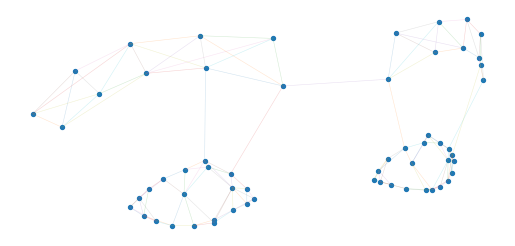

In [ ]:
# Visualization helper
def plot_face_graph(
    graph, ax=None, title=None, node_size=8, edge_alpha=0.20, edge_width=0.4
):
    """Plot one face graph using its 2D normalized landmark coordinates."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    coords = graph.x.cpu().numpy()  # Nodes of the Graph
    edge_index = graph.edge_index.cpu().numpy()  # Edges of the Graph

    xy = coords[:, :2]

    seen = set()
    for i, j in edge_index.T:
        a, b = int(i), int(j)
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        ax.plot(
            [xy[a, 0], xy[b, 0]],
            [xy[a, 1], xy[b, 1]],
            linewidth=edge_width,
            alpha=edge_alpha,
        )

    ax.scatter(xy[:, 0], xy[:, 1], s=node_size)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    if title is not None:
        ax.set_title(title)

    return ax


fig, ax = plt.subplots()
idx = random.randint(0, len(train_dataset) - 1)
graph = train_dataset[idx]
x, y = graph.x, graph.y
plot_face_graph(graph, ax)


# Understanding the samples
# 1) graph.x: (Num_nodes, 3) matrix. The coordinates (x1,x2,x3) of the facial landmarks, normalized to [-1,1]. Those are the node features of the graph.
# 2) graph.edge_index: (2, Num_edges) matrix. The edges of the graph, where each column (i,j) represents an edge from node i to node j.
# 3) graph.y: The label of the graph, where 0 means "alert" and 1 means "drowsy". This is the target variable we want to predict.
# 4) You can safely ignore the other 2 attributes of the graph (source_index and eye_openness) for this assignment.
# For completeness, eye_openness is a score in [0,1] that indicates how open the eyes are, and source_index is an index corresponding to the sample index with respect to the original dataset before graph construction.

# Task 2

In [8]:
class _BaseImageClassificationDataset(Dataset):
    """
    Base dataset for image classification datasets stored as:

        dataset_dir/
            class_to_id.json
            id_to_class.json
            train/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
            test/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
    """

    def __init__(
        self,
        dataset_dir,
        split="train",
        img_transform=None,
    ):
        super().__init__()
        self.dataset_dir = Path(dataset_dir)
        self.split = split
        self.img_transform = img_transform

        if self.split not in {"train", "test"}:
            raise ValueError(f"split must be 'train' or 'test', got: {self.split}")

        self.split_dir = self.dataset_dir / self.split
        self.labels_path = self.split_dir / "labels.csv"
        self.class_to_id_path = self.dataset_dir / "class_to_id.json"
        self.id_to_class_path = self.dataset_dir / "id_to_class.json"

        if not self.dataset_dir.exists():
            raise FileNotFoundError(f"Dataset directory not found: {self.dataset_dir}")
        if not self.split_dir.exists():
            raise FileNotFoundError(f"Split directory not found: {self.split_dir}")
        if not self.labels_path.exists():
            raise FileNotFoundError(f"labels.csv not found: {self.labels_path}")
        if not self.class_to_id_path.exists():
            raise FileNotFoundError(
                f"class_to_id.json not found: {self.class_to_id_path}"
            )
        if not self.id_to_class_path.exists():
            raise FileNotFoundError(
                f"id_to_class.json not found: {self.id_to_class_path}"
            )

        with open(self.class_to_id_path, "r") as fp:
            self.class_to_id = json.load(fp)

        with open(self.id_to_class_path, "r") as fp:
            self.id_to_class = json.load(fp)

        # Normalize keys for convenience
        self.id_to_class = {int(k): v for k, v in self.id_to_class.items()}
        self.num_classes = len(self.class_to_id)
        self.classes = [self.id_to_class[i] for i in range(self.num_classes)]

        self.labels = (
            pd.read_csv(self.labels_path, header=None).iloc[:, 0].astype(int).tolist()
        )

        self.img_paths = sorted(
            [
                p
                for p in self.split_dir.iterdir()
                if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ],
            key=lambda p: p.name,
        )

        if len(self.img_paths) != len(self.labels):
            raise ValueError(
                f"Mismatch between number of images ({len(self.img_paths)}) and "
                f"labels ({len(self.labels)}) in split '{self.split}'."
            )

    def __len__(self):
        return len(self.labels)

    def _load_image(self, img_path):
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.img_transform is not None:
                img = self.img_transform(img)
            return img

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = self._load_image(img_path)
        label = self.labels[idx]

        return image, label


class BDDObjectClassificationDataset(_BaseImageClassificationDataset):
    """
    Dataset for the cropped-object classification dataset.

    Returns:
        image, label
    or:
        image, label, metadata   (if return_metadata=True)

    Notes:
        - img_transform defaults to None.
        - The user is responsible for resizing / tensor conversion.
    """

    pass


class PatchShuffle:
    def __init__(self, patch_size=8):
        self.p = patch_size

    def __call__(self, img):
        # Input: [C, H, W]
        c, h, w = img.shape
        p = self.p

        # 1. Unfold image into patches [C, H/p, W/p, p, p]
        patches = img.unfold(1, p, p).unfold(2, p, p)
        num_h = h // p
        num_w = w // p

        # 2. Reshape to [num_patches, C, p, p]
        patches = patches.contiguous().view(c, -1, p, p).permute(1, 0, 2, 3)

        # 3. Shuffle the patches along the first dimension
        idx = torch.randperm(patches.size(0))
        patches = patches[idx]

        # 4. Reshape back to original image dimensions
        # We need to rearrange from [num_h*num_w, C, p, p] back to [C, H, W]
        patches = patches.view(num_h, num_w, c, p, p).permute(2, 0, 3, 1, 4)
        shuffled_img = patches.contiguous().view(c, h, w)

        return shuffled_img

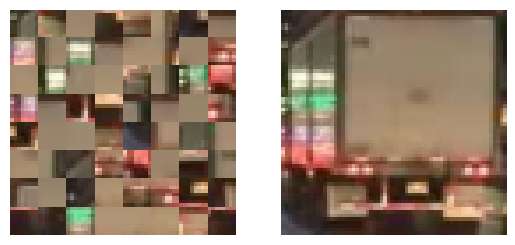

In [9]:
train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=None,  # Fill train image transforms
)

test_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=None,  # Fill test image transforms
)

### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###
from torchvision.transforms import Compose, ToTensor, Resize
from torchvision.transforms import functional as vf
import matplotlib.pyplot as plt

vis_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle(patch_size=8)]),
)
vis_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor()]),
)
fig, ax = plt.subplots(1, 2)
img_noisy, label = vis_dataset_noisy[16]
img_clean, label = vis_dataset_clean[16]
ax[0].imshow(vf.to_pil_image(img_noisy))
ax[1].imshow(vf.to_pil_image(img_clean))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_frame_on(False)
### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###

In [ ]:
from torchvision.transforms import Compose, ToTensor, Resize, Normalize
from torch.utils.data import DataLoader

IMG_SIZE   = 64   # resize all images to 64x64
PATCH_SIZE = 8
BATCH_SIZE = 32
NUM_CLASSES = 8
EPOCHS = 15

normalize = Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transform = Compose([Resize((IMG_SIZE, IMG_SIZE)), ToTensor(), normalize])
test_clean_transform = Compose([Resize((IMG_SIZE, IMG_SIZE)), ToTensor(), normalize])
test_noisy_transform = Compose([
    Resize((IMG_SIZE, IMG_SIZE)), ToTensor(),
    PatchShuffle(patch_size=PATCH_SIZE), normalize
])

obj_train = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR, split="train", img_transform=train_transform
)
obj_test_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR, split="test", img_transform=test_clean_transform
)
obj_test_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR, split="test", img_transform=test_noisy_transform
)

train_loader      = DataLoader(obj_train,      batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_clean_loader = DataLoader(obj_test_clean, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_noisy_loader = DataLoader(obj_test_noisy, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = [obj_train.id_to_class[i] for i in range(NUM_CLASSES)]
print("Classes:", class_names)
print(f"Train: {len(obj_train)}  |  Test clean: {len(obj_test_clean)}  |  Test noisy: {len(obj_test_noisy)}")


Classes: ['person', 'rider', 'car', 'truck', 'bus', 'bike', 'traffic light', 'traffic sign']
Train: 2400  |  Test clean: 240  |  Test noisy: 240


In [11]:
class PatchEmbedding(nn.Module):
    """Splits an image into non-overlapping patches and projects each to embed_dim."""
    def __init__(self, patch_size=8, in_channels=3, embed_dim=128):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Linear(in_channels * patch_size * patch_size, embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        x = x.unfold(2, p, p).unfold(3, p, p)          # [B, C, H//p, W//p, p, p]
        x = x.contiguous().view(B, C, -1, p, p)         # [B, C, N, p, p]
        x = x.permute(0, 2, 1, 3, 4).contiguous()       # [B, N, C, p, p]
        x = x.view(B, x.size(1), -1)                    # [B, N, C*p*p]
        return self.proj(x)                              # [B, N, embed_dim]


class MiniViT(nn.Module):
    """
    Vision Transformer without positional encoding.

    Transformer block structure:
    Multi-head self-attention → residual + LayerNorm → MLP → residual + LayerNorm
    """
    def __init__(self, img_size=64, patch_size=8, in_channels=3,
                 embed_dim=128, num_heads=4, num_layers=4,
                 mlp_dim=256, dropout=0.1, num_classes=8):
        super().__init__()
        self.patch_embed = PatchEmbedding(patch_size, in_channels, embed_dim)

        # Learnable CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        # Standard Transformer encoder block 
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=mlp_dim, dropout=dropout,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers, enable_nested_tensor=False)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        tokens = self.patch_embed(x)                     # [B, N, D]
        cls = self.cls_token.expand(B, -1, -1)           # [B, 1, D]
        tokens = torch.cat([cls, tokens], dim=1)         # [B, N+1, D]
        tokens = self.transformer(tokens)                # [B, N+1, D]
        cls_out = self.norm(tokens[:, 0])                # [B, D] — CLS token only
        return self.head(cls_out)                        # [B, num_classes]


model = MiniViT(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=3,
    embed_dim=128, num_heads=4, num_layers=4, mlp_dim=256,
    dropout=0.1, num_classes=NUM_CLASSES,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"MiniViT — trainable parameters: {total_params:,}")

MiniViT — trainable parameters: 556,040


In [13]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

train_losses, test_noisy_losses = [], []

for epoch in range(EPOCHS):
    # ── Training ──
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_losses.append(running_loss / len(obj_train))

    # ── Evaluation on noisy test set ──
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for imgs, labels in test_noisy_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            loss = criterion(model(imgs), labels)
            running_loss += loss.item() * imgs.size(0)
    test_noisy_losses.append(running_loss / len(obj_test_noisy))

    scheduler.step()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  "
              f"train_loss={train_losses[-1]:.4f}  "
              f"test_noisy_loss={test_noisy_losses[-1]:.4f}")

print("Training complete.")


Epoch   1/15  train_loss=2.0705  test_noisy_loss=1.9315
Epoch   5/15  train_loss=1.8323  test_noisy_loss=1.7593
Epoch  10/15  train_loss=1.6078  test_noisy_loss=1.7409
Epoch  15/15  train_loss=1.3482  test_noisy_loss=1.6672
Training complete.


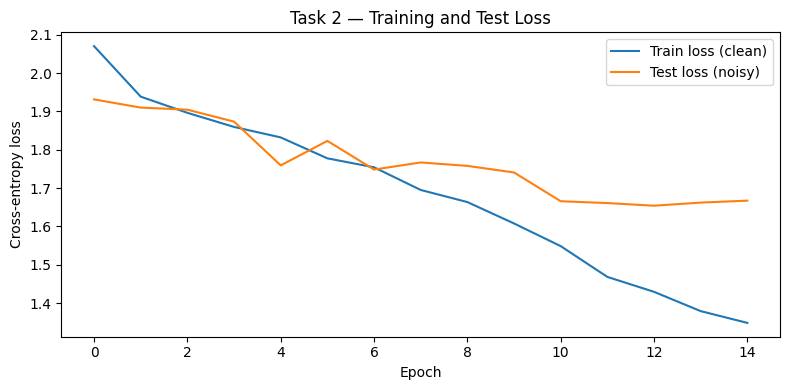

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses,       label="Train loss (clean)")
ax.plot(test_noisy_losses,  label="Test loss (noisy)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Task 2 — Training and Test Loss")
ax.legend()
plt.tight_layout()
plt.show()


In [15]:
def compute_per_class_metrics(model, loader, num_classes, device):
    """Returns per-class (precision, recall) arrays and flat (preds, labels)."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu()
            all_preds.append(preds)
            all_labels.append(labels)

    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()

    precisions, recalls = [], []
    for c in range(num_classes):
        tp = int(((preds == c) & (labels == c)).sum())
        fp = int(((preds == c) & (labels != c)).sum())
        fn = int(((preds != c) & (labels == c)).sum())
        precisions.append(tp / (tp + fp) if (tp + fp) > 0 else 0.0)
        recalls.append(   tp / (tp + fn) if (tp + fn) > 0 else 0.0)

    return np.array(precisions), np.array(recalls)


# Compute on noisy test set
prec_noisy, rec_noisy = compute_per_class_metrics(model, test_noisy_loader, NUM_CLASSES, DEVICE)

# Compute on clean test set
prec_clean, rec_clean = compute_per_class_metrics(model, test_clean_loader, NUM_CLASSES, DEVICE)

print("=== Noisy test set ===")
for i, name in enumerate(class_names):
    print(f"  {name:<15}  prec={prec_noisy[i]:.3f}  rec={rec_noisy[i]:.3f}")
print(f"  {'MACRO AVG':<15}  prec={prec_noisy.mean():.3f}  rec={rec_noisy.mean():.3f}")

print()
print("=== Clean test set ===")
for i, name in enumerate(class_names):
    print(f"  {name:<15}  prec={prec_clean[i]:.3f}  rec={rec_clean[i]:.3f}")
print(f"  {'MACRO AVG':<15}  prec={prec_clean.mean():.3f}  rec={rec_clean.mean():.3f}")


=== Noisy test set ===
  person           prec=0.211  rec=0.133
  rider            prec=0.250  rec=0.200
  car              prec=0.293  rec=0.400
  truck            prec=0.500  rec=0.367
  bus              prec=0.211  rec=0.267
  bike             prec=0.310  rec=0.433
  traffic light    prec=0.760  rec=0.633
  traffic sign     prec=0.621  rec=0.600
  MACRO AVG        prec=0.394  rec=0.379

=== Clean test set ===
  person           prec=0.211  rec=0.133
  rider            prec=0.250  rec=0.200
  car              prec=0.293  rec=0.400
  truck            prec=0.500  rec=0.367
  bus              prec=0.211  rec=0.267
  bike             prec=0.310  rec=0.433
  traffic light    prec=0.760  rec=0.633
  traffic sign     prec=0.621  rec=0.600
  MACRO AVG        prec=0.394  rec=0.379


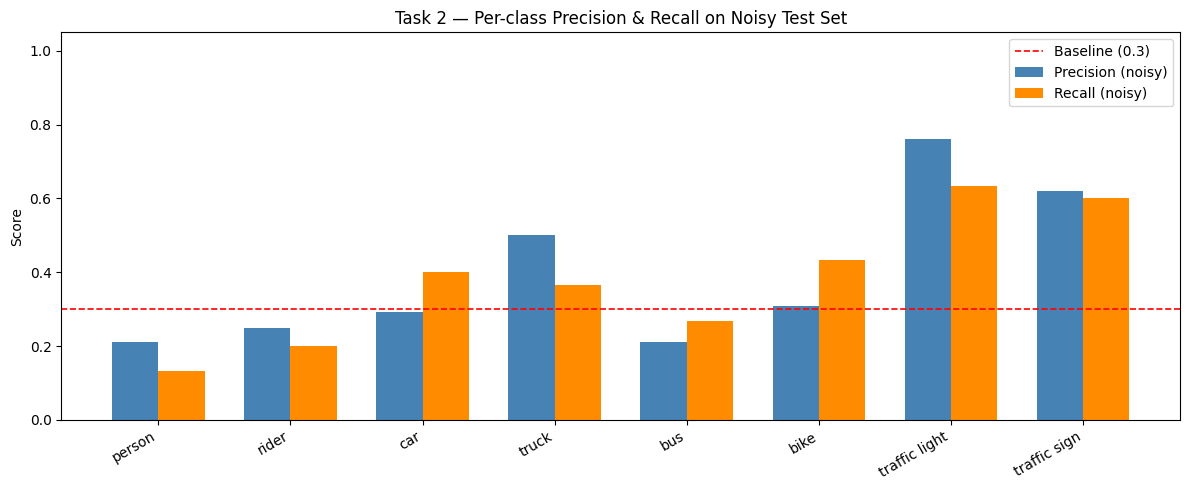

Noisy  — macro precision: 0.3942  |  macro recall: 0.3792
Clean  — macro precision: 0.3942  |  macro recall: 0.3792


In [ ]:
x = np.arange(NUM_CLASSES)
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, prec_noisy, w, label="Precision (noisy)", color="steelblue")
ax.bar(x + w/2, rec_noisy,  w, label="Recall (noisy)",    color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Task 2 — Per-class Precision & Recall on Noisy Test Set")
ax.axhline(0.3, color="red", linestyle="--", linewidth=1.2, label="Baseline (0.3)")
ax.legend()
plt.tight_layout()
plt.show()

# 4 aggregate scalars 
print(f"Noisy  — macro precision: {prec_noisy.mean():.4f}  |  macro recall: {rec_noisy.mean():.4f}")
print(f"Clean  — macro precision: {prec_clean.mean():.4f}  |  macro recall: {rec_clean.mean():.4f}")


## Task 3 

In [ ]:
import torchvision.models as models

class LinearProbeClassifier(nn.Module):
    """
    Frozen pretrained backbone + trainable linear classification head.

    freeze the pretrained backbone, replace its classification head with a new trainable linear layer
    """

    def __init__(self, backbone_arch: str, num_classes: int):
        super().__init__()

        # Load pretrained backbone from torchvision using the architecture name string
        weights = models.get_model_weights(backbone_arch).DEFAULT
        self.backbone = models.get_model(backbone_arch, weights=weights)

        # ViT has a heads module — get its feature dimension then replace with Identity
        # Identity returns its input unchanged, so backbone now outputs raw features
        in_features = self.backbone.heads.head.in_features
        self.backbone.heads = nn.Identity()

        # Freeze all pretrained backbone parameters (no gradient updates)
        for param in self.backbone.parameters():
            param.requires_grad = False

        # New trainable linear classification head for the 8 BDD classes
        self.linear_head = nn.Linear(in_features, num_classes)

    def forward(self, x: torch.Tensor):
        features = self.backbone(x)        # frozen feature extraction [B, 768]
        return self.linear_head(features)  # trainable linear classifier [B, num_classes]


# pretrained model's own preprocessing (224x224, ImageNet stats)
t3_weights = models.get_model_weights("vit_b_16").DEFAULT
t3_transform = t3_weights.transforms()  # resize to 224, normalize with ImageNet stats

t3_train = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR, split="train", img_transform=t3_transform
)
t3_test = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR, split="test", img_transform=t3_transform
)
t3_train_loader = DataLoader(t3_train, batch_size=32, shuffle=True,  num_workers=0)
t3_test_loader  = DataLoader(t3_test,  batch_size=32, shuffle=False, num_workers=0)

probe_model = LinearProbeClassifier(backbone_arch="vit_b_16", num_classes=NUM_CLASSES).to(DEVICE)
trainable = sum(p.numel() for p in probe_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in probe_model.parameters())
print(f"Trainable parameters: {trainable:,}  /  Total: {total:,}")
print(f"Backbone frozen: {not any(p.requires_grad for p in probe_model.backbone.parameters())}")

Trainable parameters: 6,152  /  Total: 85,804,808
Backbone frozen: True


In [ ]:
# Train only the linear head (backbone stays frozen)
# max 10 epochs for linear probing
T3_EPOCHS = 10
optimizer_t3 = torch.optim.Adam(probe_model.linear_head.parameters(), lr=1e-3)
criterion_t3 = nn.CrossEntropyLoss()

for epoch in range(T3_EPOCHS):
    probe_model.train()
    probe_model.backbone.eval()  # keep backbone in eval mode (frozen dropout/batchnorm)
    running_loss = 0.0
    for imgs, labels in t3_train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer_t3.zero_grad()
        loss = criterion_t3(probe_model(imgs), labels)
        loss.backward()
        optimizer_t3.step()
        running_loss += loss.item() * imgs.size(0)
    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{T3_EPOCHS}  loss={running_loss/len(t3_train):.4f}")

print("Linear probe training complete.")

Epoch  1/10  loss=1.4132
Epoch  2/10  loss=1.0122
Epoch  4/10  loss=0.8311
Epoch  6/10  loss=0.7399
Epoch  8/10  loss=0.6701
Epoch 10/10  loss=0.6193
Linear probe training complete.


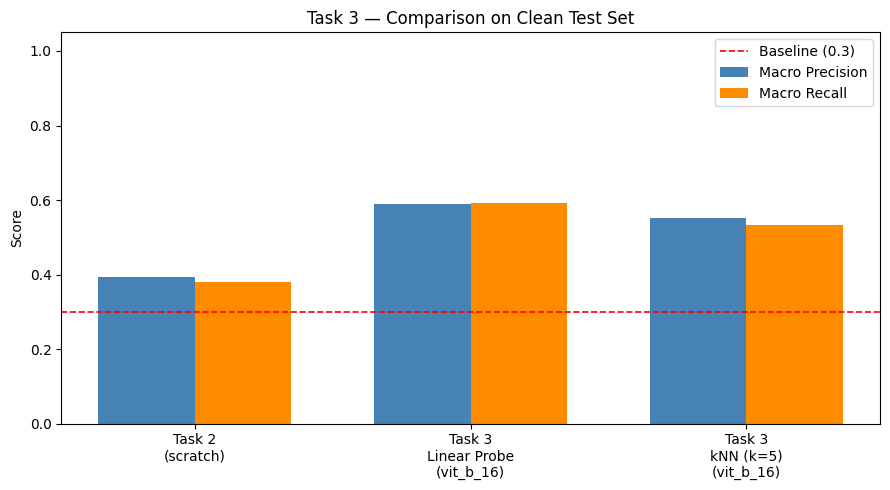

Task 2 scratch     — macro prec: 0.3942  |  macro rec: 0.3792
Task 3 linear probe — macro prec: 0.5895  |  macro rec: 0.5917
Task 3 kNN (k=5)   — macro prec: 0.5509  |  macro rec: 0.5333


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Extract frozen features for all train and test images
def extract_features(model, loader, device):
    model.eval()
    all_feats, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            feats = model.backbone(imgs.to(device)).cpu()
            all_feats.append(feats)
            all_labels.append(labels)
    return torch.cat(all_feats).numpy(), torch.cat(all_labels).numpy()

train_feats, train_labels_arr = extract_features(probe_model, t3_train_loader, DEVICE)
test_feats,  test_labels_arr  = extract_features(probe_model, t3_test_loader,  DEVICE)

# kNN classification directly in the feature space (k=5)
K = 5
knn = KNeighborsClassifier(n_neighbors=K)
knn.fit(train_feats, train_labels_arr)
knn_preds = knn.predict(test_feats)

# Metrics for linear probe
prec_probe, rec_probe = compute_per_class_metrics(probe_model, t3_test_loader, NUM_CLASSES, DEVICE)

# Metrics for kNN (computed from raw predictions)
def metrics_from_arrays(preds, labels, num_classes):
    precisions, recalls = [], []
    for c in range(num_classes):
        tp = int(((preds == c) & (labels == c)).sum())
        fp = int(((preds == c) & (labels != c)).sum())
        fn = int(((preds != c) & (labels == c)).sum())
        precisions.append(tp / (tp + fp) if (tp + fp) > 0 else 0.0)
        recalls.append(   tp / (tp + fn) if (tp + fn) > 0 else 0.0)
    return np.array(precisions), np.array(recalls)

prec_knn, rec_knn = metrics_from_arrays(knn_preds, test_labels_arr, NUM_CLASSES)

#Task 2 vs Linear Probe vs kNN
methods = [f"Task 2", f"Task 3\nLinear Probe\n(vit_b_16)", f"Task 3\nkNN (k={K})\n(vit_b_16)"]
precs   = [prec_clean.mean(), prec_probe.mean(), prec_knn.mean()]
recs    = [rec_clean.mean(),  rec_probe.mean(),  rec_knn.mean()]

x = np.arange(len(methods))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, precs, w, label="Macro Precision", color="steelblue")
ax.bar(x + w/2, recs,  w, label="Macro Recall",    color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Task 3 — Comparison on Clean Test Set")
ax.axhline(0.3, color="red", linestyle="--", linewidth=1.2, label="Baseline (0.3)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Task 2 scratch     — macro prec: {prec_clean.mean():.4f}  |  macro rec: {rec_clean.mean():.4f}")
print(f"Task 3 linear probe — macro prec: {prec_probe.mean():.4f}  |  macro rec: {rec_probe.mean():.4f}")
print(f"Task 3 kNN (k={K})   — macro prec: {prec_knn.mean():.4f}  |  macro rec: {rec_knn.mean():.4f}")